# Mask Validation Notebook

Quick visual check of ideal mask geometry **before training any model**.

Validates:
- Vertical orientation (`np.flipud` fix — teeth should point **down** in the mask)
- Scale (`px_per_mm=572` — teeth in mask should match teeth in ROI)
- Crest width (`crest_width_mm=0.19` — teeth should look nearly triangular, not flat-topped)
- Registration (`register_mask` — mask valleys should align with actual teeth)

**Run this before running Kaggle.** If the panels look wrong, fix the parameters before wasting GPU time.

In [1]:
import sys
from pathlib import Path

# Make src/ importable
ROOT = Path("..")
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from preprocessing.m2_preprocessing import separate_tool_background
from preprocessing.synthetic_mask import generate_ideal_mask, detect_thread_boundary
from preprocessing.registration import register_mask
from preprocessing.scale_calibration import load_scale_factor

print("Imports OK")

Imports OK


## 1. Configuration

Edit these values to test different parameter combinations.

Image: Imagen_000501_RB02.jpg
Tool bbox:        rows 0–1551 (1551px),  cols 0–2087 (2087px)
Analysis region:  cols 104–1565 (1461px)  [excluding shank on right]


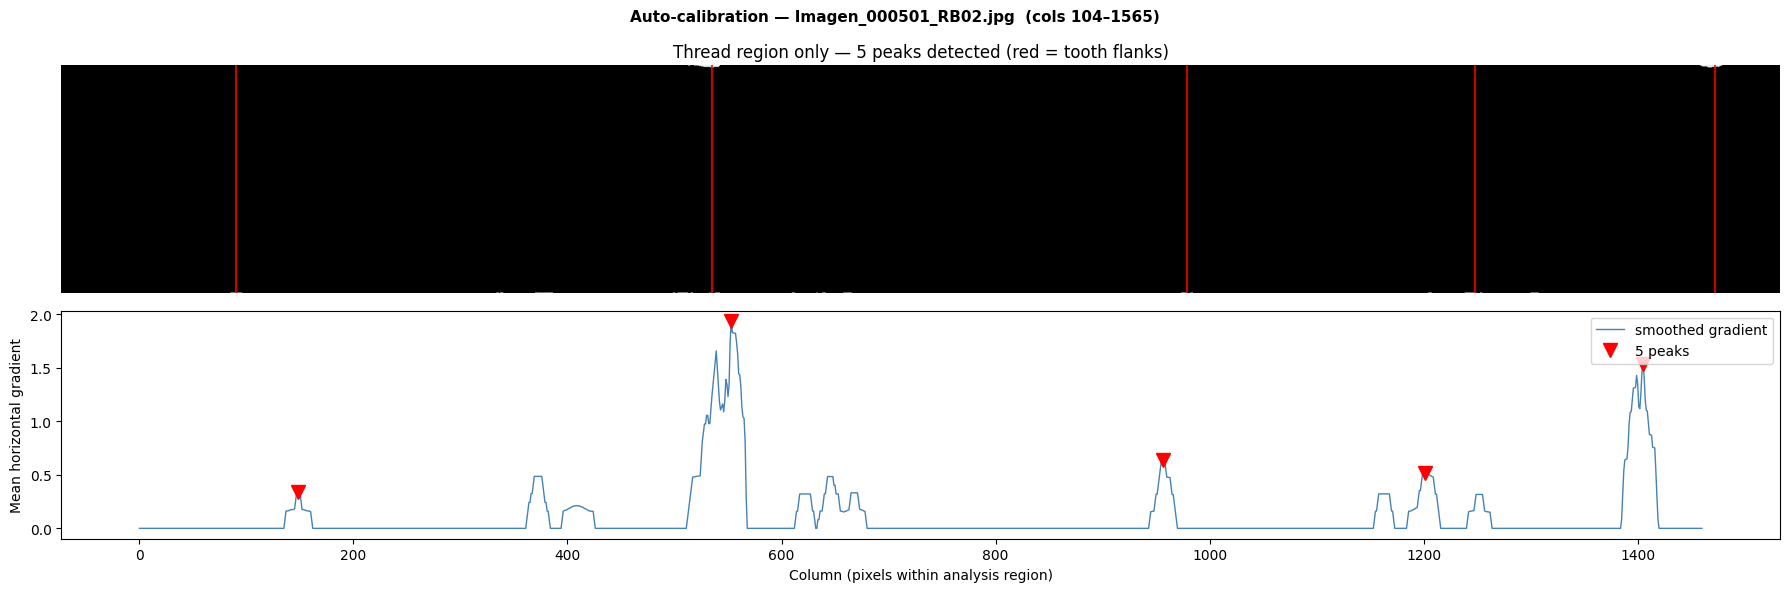


Detected 5 peaks,  spacings: [405, 403, 245, 204] px
Mean tooth pitch: 314.2 px
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Measured px_per_mm = 209.5
  → Set PX_PER_MM = 210 in the config cell below
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [2]:
## Auto-calibration: measure actual pitch from image, back-calculate px_per_mm
#
# Run this cell BEFORE the config cell and paste the result into PX_PER_MM.
#
# ADJUST THESE if the detected peaks don't match actual teeth:
_COL_START_PCT = 0.05   # skip left edge (partial tooth / shank)
_COL_END_PCT   = 0.75   # skip right edge — tap head (smooth shank, not threaded)
_ROW_START_PCT = 0.70   # analyse bottom N% of tool height where threads are visible

from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

_PITCH_MM = 1.5  # M10x1.5 — hardcoded, config not loaded yet

# RB01 has the tap head on the RIGHT side (atypical) → use RB02 as reference
_img_path = sorted((ROOT / ".." / "data" / "normal").glob("Imagen_*.jpg"))[1]
_img = cv2.imread(str(_img_path), cv2.IMREAD_GRAYSCALE)
if _img is None:
    raise FileNotFoundError(f"Cannot read {_img_path}")

_roi_mask, _tool_roi = separate_tool_background(_img)

# Bounding box (inlined)
_rows = np.any(_roi_mask > 0, axis=1)
_cols = np.any(_roi_mask > 0, axis=0)
_r0, _r1 = int(np.where(_rows)[0][0]),  int(np.where(_rows)[0][-1])
_c0, _c1 = int(np.where(_cols)[0][0]),  int(np.where(_cols)[0][-1])

# Apply column exclusion for shank/head
_tool_w = _c1 - _c0
_ca = _c0 + int(_tool_w * _COL_START_PCT)
_cb = _c0 + int(_tool_w * _COL_END_PCT)

print(f"Image: {_img_path.name}")
print(f"Tool bbox:        rows {_r0}–{_r1} ({_r1-_r0}px),  cols {_c0}–{_c1} ({_tool_w}px)")
print(f"Analysis region:  cols {_ca}–{_cb} ({_cb-_ca}px)  [excluding shank on right]")

# Bottom strip (thread profile)
_bottom_start = _r0 + int((_r1 - _r0) * _ROW_START_PCT)
_strip = _tool_roi[_bottom_start:_r1, _ca:_cb].astype(np.float32)

# Horizontal gradient → column profile → peaks
_grad = np.abs(cv2.Sobel(_strip, cv2.CV_32F, 1, 0, ksize=3))
_col_profile = _grad.mean(axis=0)
_smooth = uniform_filter1d(_col_profile, size=15)

_rough_dist = max(int(_strip.shape[1] / 8), 20)
_peaks, _ = find_peaks(_smooth, distance=_rough_dist, prominence=_smooth.max() * 0.1)

fig, axes = plt.subplots(2, 1, figsize=(18, 6))
fig.suptitle(f"Auto-calibration — {_img_path.name}  (cols {_ca}–{_cb})", fontsize=11, fontweight="bold")

axes[0].imshow(_strip, cmap="gray", aspect="auto")
for p in _peaks:
    axes[0].axvline(p, color="red", linewidth=1.5, alpha=0.8)
axes[0].set_title(f"Thread region only — {len(_peaks)} peaks detected (red = tooth flanks)")
axes[0].axis("off")

axes[1].plot(_smooth, linewidth=1, color="steelblue", label="smoothed gradient")
axes[1].plot(_peaks, _smooth[_peaks], "rv", markersize=10, label=f"{len(_peaks)} peaks")
axes[1].set_xlabel("Column (pixels within analysis region)")
axes[1].set_ylabel("Mean horizontal gradient")
axes[1].legend()
plt.tight_layout()
plt.show()

if len(_peaks) >= 2:
    _spacings = np.diff(_peaks)
    _mean_spacing = float(_spacings.mean())
    _measured_px_mm = _mean_spacing / _PITCH_MM
    print(f"\nDetected {len(_peaks)} peaks,  spacings: {[int(s) for s in _spacings]} px")
    print(f"Mean tooth pitch: {_mean_spacing:.1f} px")
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"  Measured px_per_mm = {_measured_px_mm:.1f}")
    print(f"  → Set PX_PER_MM = {_measured_px_mm:.0f} in the config cell below")
    print(f"━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
else:
    print(f"\nWARNING: only {len(_peaks)} peaks found.")
    print("Adjust _COL_END_PCT (e.g. 0.60) to exclude more of the shank,")
    print("or _ROW_START_PCT (e.g. 0.50) if threads start higher in the image.")

In [3]:
# ── Scale ────────────────────────────────────────────────────────────────────
SCALE_FILE = ROOT / "scale_factor.json"
if SCALE_FILE.exists():
    PX_PER_MM = load_scale_factor(SCALE_FILE)
    print(f"Scale loaded from file: {PX_PER_MM} px/mm")
else:
    PX_PER_MM = 572.0
    print(f"Scale hardcoded: {PX_PER_MM} px/mm")

# ── Thread geometry (M10x1.5 ISO) ────────────────────────────────────────────
PITCH_MM        = 1.5    # distance between consecutive teeth [mm]
THREAD_H_MM     = 0.76   # height from valley to crest [mm]
CREST_WIDTH_MM  = 0.19   # flat crest width [mm]  (ISO: P/8 = 0.1875 mm)
VALLEY_WIDTH_MM = 0.19   # flat valley width [mm]

# ── Images to validate ───────────────────────────────────────────────────────
# Data lives one level above the project root (../data relative to jordi/)
DATA_DIR = ROOT / ".." / "data"
NORMAL_IMAGES = sorted((DATA_DIR / "normal").glob("Imagen_*.jpg"))[:3]
WORN_IMAGES   = sorted((DATA_DIR / "worn").glob("Imagen_*.jpg"))[:3]
SAMPLE_IMAGES = NORMAL_IMAGES + WORN_IMAGES

if not NORMAL_IMAGES:
    raise FileNotFoundError(f"No images found in {DATA_DIR / 'normal'}. Check DATA_DIR path.")

print(f"Data dir:      {DATA_DIR.resolve()}")
print(f"Normal images: {[p.name for p in NORMAL_IMAGES]}")
print(f"Worn images:   {[p.name for p in WORN_IMAGES]}")

Scale loaded from file: 572.0 px/mm
Data dir:      /Users/jordi/Repositories/TFM-desgaste/data
Normal images: ['Imagen_000501_RB01.jpg', 'Imagen_000501_RB02.jpg', 'Imagen_000501_RB03.jpg']
Worn images:   ['Imagen_000501_RM01.jpg', 'Imagen_000501_RM02.jpg', 'Imagen_000501_RM03.jpg']


## 2. Helper functions

In [4]:
def load_roi(img_path: Path):
    """Load image, separate tool from background, return (roi_mask, tool_roi)."""
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read: {img_path}")
    roi_mask, tool_roi = separate_tool_background(img)
    return roi_mask, tool_roi


def build_ideal(roi_mask, tool_roi, flip=True):
    """
    Generate ideal mask positioned at the detected thread boundary, flip, register.

    detect_thread_boundary() finds where the dark tap body transitions to the
    thread profile zone. center_row = H - 1 - boundary puts the mask valley at
    the correct vertical position before registration fine-tunes it.

    Returns (registered_mask, confidence, boundary_row).
    """
    H, W = roi_mask.shape
    boundary = detect_thread_boundary(tool_roi)
    center_row = H - 1 - boundary
    ideal = generate_ideal_mask(
        px_per_mm=PX_PER_MM,
        image_shape=(H, W),
        pitch_mm=PITCH_MM,
        thread_height_mm=THREAD_H_MM,
        crest_width_mm=CREST_WIDTH_MM,
        valley_width_mm=VALLEY_WIDTH_MM,
        center_row=center_row,
    )
    if flip:
        ideal = np.flipud(ideal)
    registered, confidence = register_mask(tool_roi, ideal, roi_mask)
    return registered, confidence, boundary


def tool_bbox(roi_mask):
    """Return (r0, r1, c0, c1) bounding box of the tool region."""
    rows = np.any(roi_mask > 0, axis=1)
    cols = np.any(roi_mask > 0, axis=0)
    r0, r1 = np.where(rows)[0][[0, -1]]
    c0, c1 = np.where(cols)[0][[0, -1]]
    return int(r0), int(r1), int(c0), int(c1)


def show_4panel(tool_roi, ideal, title="", pred=None, roi_mask=None):
    """
    Display [ROI | pred | ideal | diff].
    If roi_mask provided, crops display to tool bounding box for clarity.
    """
    if pred is None:
        pred = np.zeros_like(ideal)

    if roi_mask is not None:
        r0, r1, c0, c1 = tool_bbox(roi_mask)
        tool_roi = tool_roi[r0:r1, c0:c1]
        ideal    = ideal[r0:r1, c0:c1]
        pred     = pred[r0:r1, c0:c1]

    diff = cv2.absdiff(ideal, pred)
    diff_rgb = cv2.applyColorMap(diff, cv2.COLORMAP_HOT)
    diff_rgb = cv2.cvtColor(diff_rgb, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle(title, fontsize=11, fontweight="bold")

    axes[0].imshow(tool_roi, cmap="gray");  axes[0].set_title("ROI original")
    axes[1].imshow(pred,     cmap="gray");  axes[1].set_title("Predicted mask")
    axes[2].imshow(ideal,    cmap="gray");  axes[2].set_title("Ideal mask")
    axes[3].imshow(diff_rgb);               axes[3].set_title("Diff (HOT)")

    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


print("Helpers defined")

Helpers defined


## 3. Orientation check

**What to look for:** the ideal mask (panel 3) should have its tooth valleys pointing **downward**, matching the actual tooth profile in panel 1 (ROI).

The diff panel should be mostly dark (small discrepancy between ideal and the bottom boundary of the ROI).

Image size:        2088 × 1552 px
Tool bounding box: rows 0–1551  cols 0–2087

detect_thread_boundary → boundary_row = 660  (row where dark body → thread zone)
center_row for generate_ideal_mask = H-1-660 = 891
Registration confidence: 0.660  (>0.3 = shift applied)


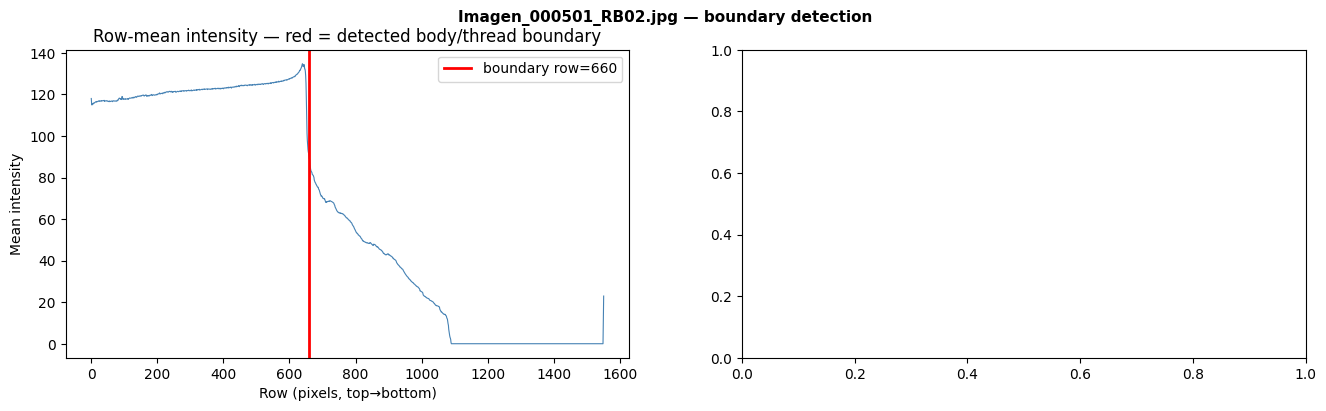

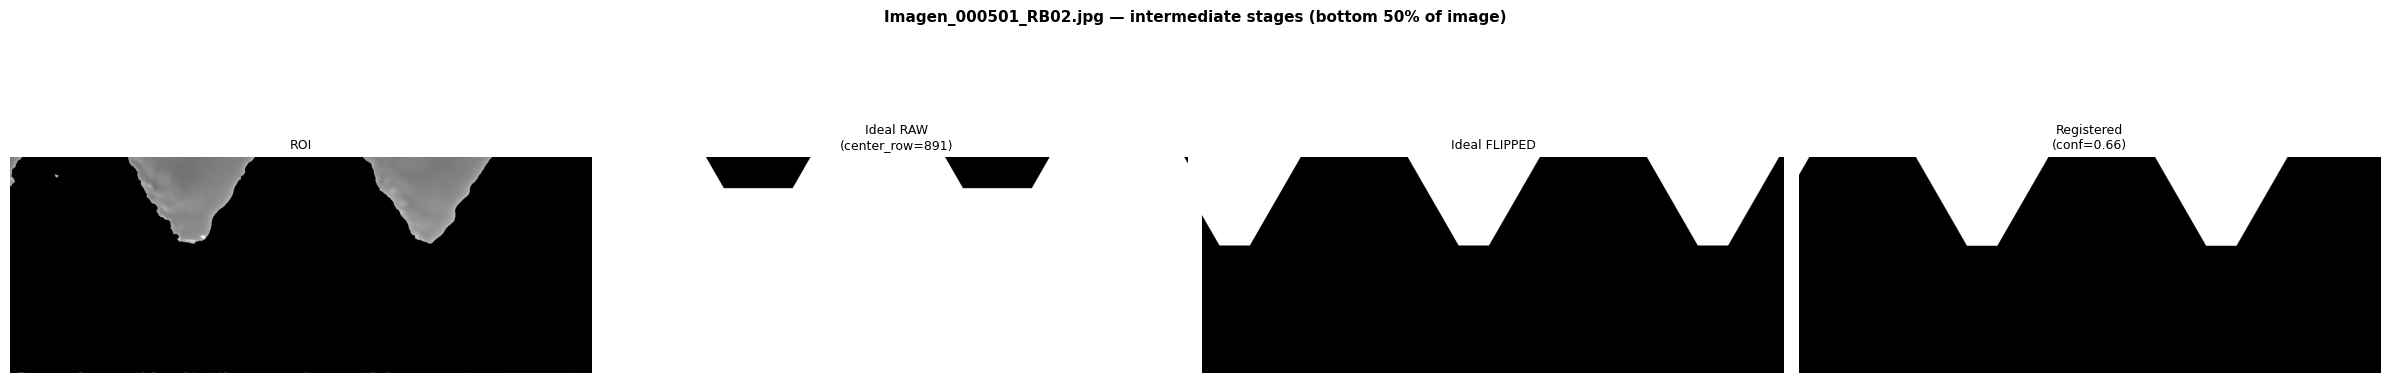

In [5]:
## Diagnostic: boundary detection + intermediate mask stages for first image
# RB01 has tap head on right (atypical) — use RB02 as reference
img_path = SAMPLE_IMAGES[1]
roi_mask, tool_roi = load_roi(img_path)
H, W = roi_mask.shape

r0, r1, c0, c1 = tool_bbox(roi_mask)
print(f"Image size:        {W} × {H} px")
print(f"Tool bounding box: rows {r0}–{r1}  cols {c0}–{c1}")

# Row-mean intensity profile — shows where body ends and thread zone starts
row_mean = tool_roi.mean(axis=1)
boundary = detect_thread_boundary(tool_roi)
center_row = H - 1 - boundary
print(f"\ndetect_thread_boundary → boundary_row = {boundary}  (row where dark body → thread zone)")
print(f"center_row for generate_ideal_mask = H-1-{boundary} = {center_row}")

# Generate ideal at detected center_row
ideal_raw = generate_ideal_mask(
    px_per_mm=PX_PER_MM, image_shape=(H, W),
    pitch_mm=PITCH_MM, thread_height_mm=THREAD_H_MM,
    crest_width_mm=CREST_WIDTH_MM, valley_width_mm=VALLEY_WIDTH_MM,
    center_row=center_row,
)
ideal_flipped = np.flipud(ideal_raw)
ideal_registered, confidence = register_mask(tool_roi, ideal_flipped, roi_mask)
print(f"Registration confidence: {confidence:.3f}  (>0.3 = shift applied)")

# Show row-mean profile with boundary marker
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle(f"{img_path.name} — boundary detection", fontsize=11, fontweight="bold")

axes[0].plot(row_mean, linewidth=0.8, color="steelblue")
axes[0].axvline(boundary, color="red", linewidth=2, label=f"boundary row={boundary}")
axes[0].set_xlabel("Row (pixels, top→bottom)")
axes[0].set_ylabel("Mean intensity")
axes[0].set_title("Row-mean intensity — red = detected body/thread boundary")
axes[0].legend()

# Show 4 intermediate stages cropped to thread zone (bottom 50% of image)
crop_start = H // 2
stages = [
    (tool_roi,         "ROI"),
    (ideal_raw,        f"Ideal RAW\n(center_row={center_row})"),
    (ideal_flipped,    "Ideal FLIPPED"),
    (ideal_registered, f"Registered\n(conf={confidence:.2f})"),
]
fig2, axes2 = plt.subplots(1, 4, figsize=(24, 5))
fig2.suptitle(f"{img_path.name} — intermediate stages (bottom 50% of image)", fontsize=11, fontweight="bold")
for ax, (img_arr, lbl) in zip(axes2, stages):
    ax.imshow(img_arr[crop_start:, :], cmap="gray")
    ax.set_title(lbl, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

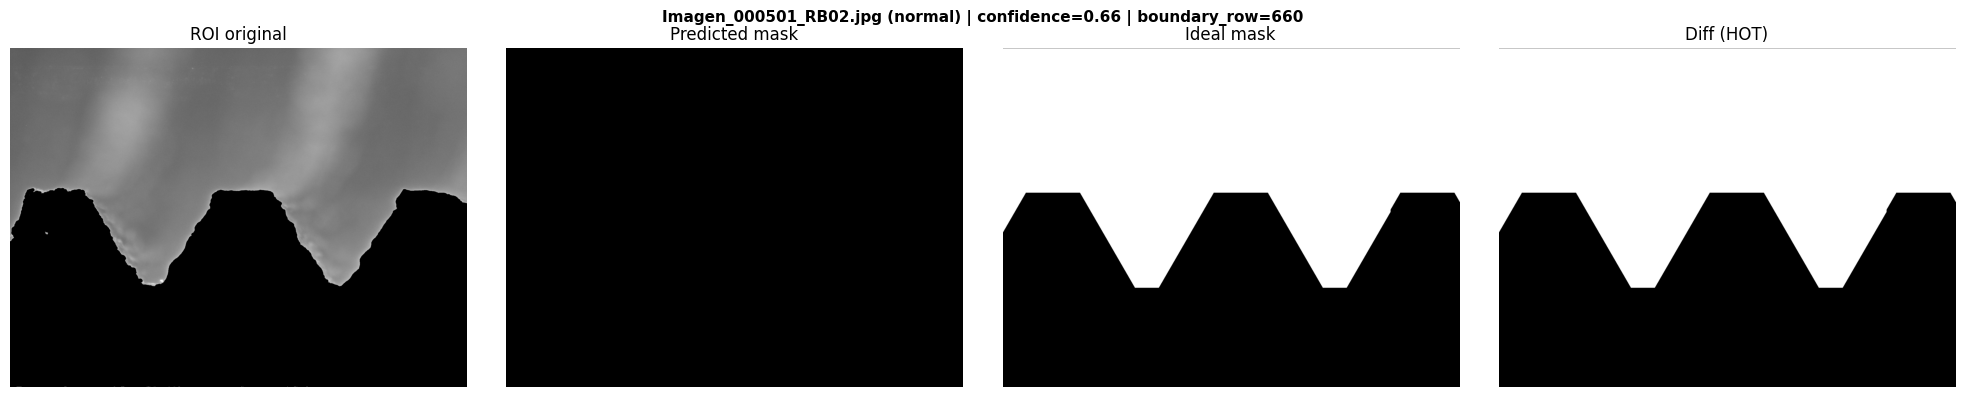

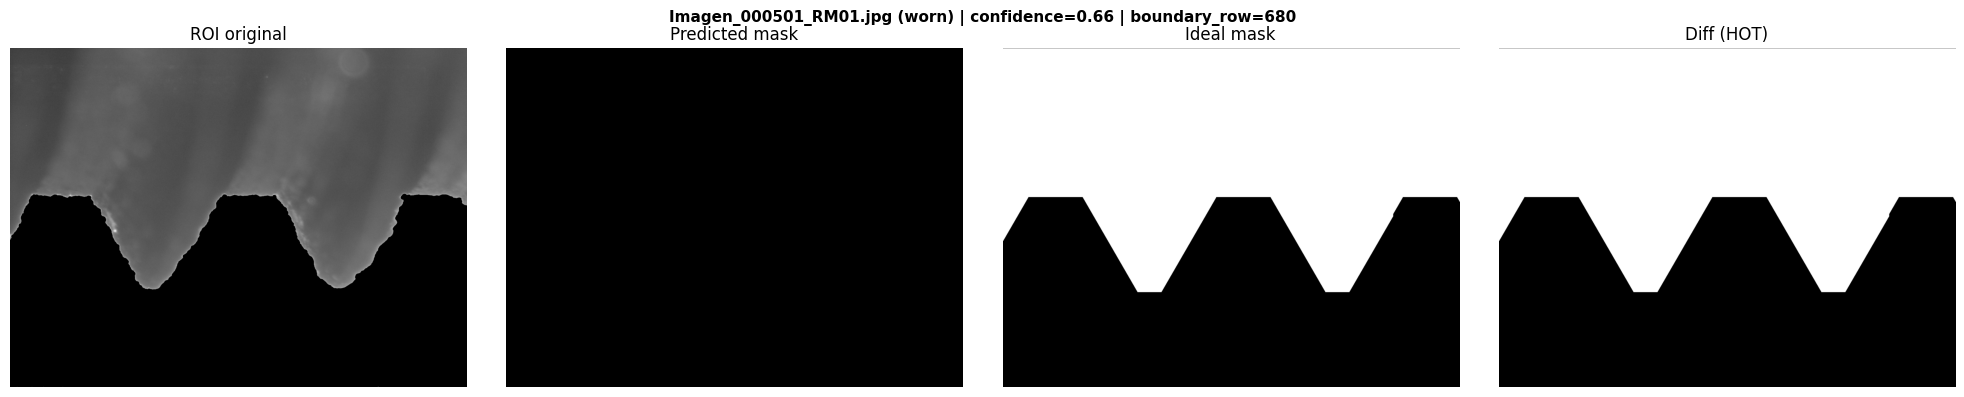


✓ Check: tooth valleys in ideal (panel 3) point DOWNWARD to match ROI (panel 1)


In [6]:
# RB01 has tap head on right (atypical) — skip it; show RB02 (normal) + RM01 (worn)
for img_path in [SAMPLE_IMAGES[1], SAMPLE_IMAGES[3]]:
    roi_mask, tool_roi = load_roi(img_path)
    ideal, confidence, boundary = build_ideal(roi_mask, tool_roi, flip=True)
    label = "normal" if img_path.parent.name == "normal" else "worn"
    show_4panel(
        tool_roi, ideal,
        title=f"{img_path.name} ({label}) | confidence={confidence:.2f} | boundary_row={boundary}",
        roi_mask=roi_mask,
    )

print("\n✓ Check: tooth valleys in ideal (panel 3) point DOWNWARD to match ROI (panel 1)")

## 4. Flip comparison (before vs after fix)

Side-by-side to confirm the `np.flipud` fix is correct.

**Before fix (flip=False):** valleys at the top — WRONG  
**After fix (flip=True):** valleys at the bottom — CORRECT

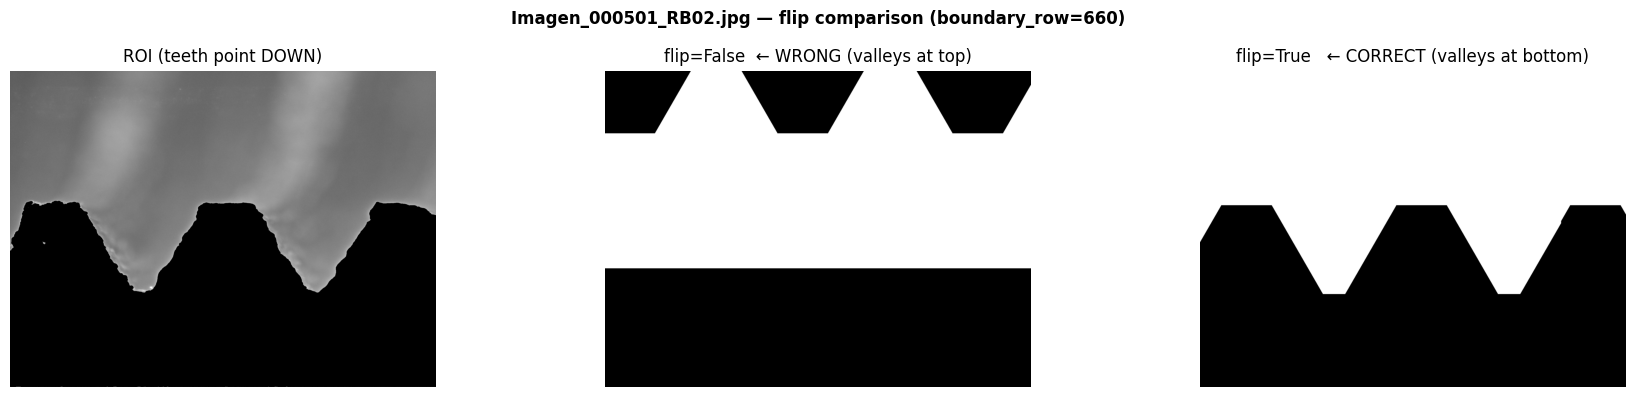

In [7]:
# RB01 has tap head on right (atypical) — use RB02 as reference
img_path = SAMPLE_IMAGES[1]
roi_mask, tool_roi = load_roi(img_path)

ideal_no_flip, _, boundary = build_ideal(roi_mask, tool_roi, flip=False)
ideal_flipped, _, _        = build_ideal(roi_mask, tool_roi, flip=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle(f"{img_path.name} — flip comparison (boundary_row={boundary})", fontsize=12, fontweight="bold")

axes[0].imshow(tool_roi, cmap="gray")
axes[0].set_title("ROI (teeth point DOWN)")

axes[1].imshow(ideal_no_flip, cmap="gray")
axes[1].set_title("flip=False  ← WRONG (valleys at top)")

axes[2].imshow(ideal_flipped, cmap="gray")
axes[2].set_title("flip=True   ← CORRECT (valleys at bottom)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Tooth geometry detail

Zoom into the tooth profile region to inspect:
- **Crest width:** should look nearly triangular (narrow flat top), not like a plateau
- **Flank angle:** approximately 60° on each side
- **Tooth height:** should match visible depth of actual teeth in ROI
- **Pitch:** same number of teeth visible in ROI and in ideal mask

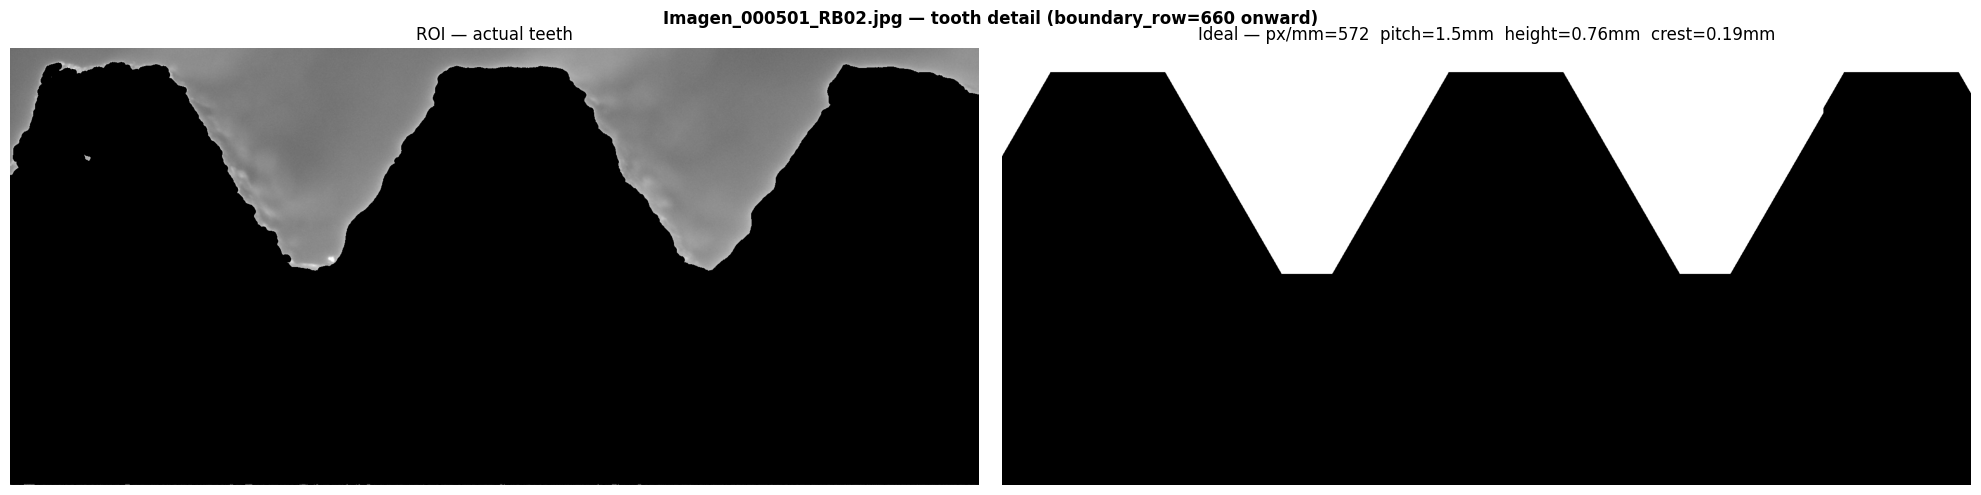

Expected tooth pitch:  858 px  (1.5 mm × 572.0 px/mm)
Expected tooth height: 435 px  (0.76 mm × 572.0 px/mm)
Expected crest width:  109 px  (0.19 mm × 572.0 px/mm)
Expected teeth in 2088px wide ROI: 2.4
Detected thread boundary at row 660 (43% from top)


In [8]:
# RB01 has tap head on right (atypical) — use RB02 as reference
img_path = SAMPLE_IMAGES[1]
roi_mask, tool_roi = load_roi(img_path)
ideal, _, boundary = build_ideal(roi_mask, tool_roi, flip=True)

H, W = ideal.shape

# Crop to thread zone: from boundary_row to image bottom
crop_top = max(0, boundary - 50)   # 50px above detected boundary for context
crop_bot = H

roi_crop   = tool_roi[crop_top:crop_bot, :]
ideal_crop = ideal[crop_top:crop_bot, :]

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle(f"{img_path.name} — tooth detail (boundary_row={boundary} onward)", fontsize=12, fontweight="bold")

axes[0].imshow(roi_crop, cmap="gray")
axes[0].set_title("ROI — actual teeth")

axes[1].imshow(ideal_crop, cmap="gray")
axes[1].set_title(
    f"Ideal — px/mm={PX_PER_MM:.0f}  pitch={PITCH_MM}mm  "
    f"height={THREAD_H_MM}mm  crest={CREST_WIDTH_MM}mm"
)

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Print expected tooth dimensions in pixels
pitch_px  = PITCH_MM * PX_PER_MM
height_px = THREAD_H_MM * PX_PER_MM
crest_px  = CREST_WIDTH_MM * PX_PER_MM
print(f"Expected tooth pitch:  {pitch_px:.0f} px  ({PITCH_MM} mm × {PX_PER_MM} px/mm)")
print(f"Expected tooth height: {height_px:.0f} px  ({THREAD_H_MM} mm × {PX_PER_MM} px/mm)")
print(f"Expected crest width:  {crest_px:.0f} px  ({CREST_WIDTH_MM} mm × {PX_PER_MM} px/mm)")
print(f"Expected teeth in {W}px wide ROI: {W/pitch_px:.1f}")
print(f"Detected thread boundary at row {boundary} ({boundary/H*100:.0f}% from top)")

## 6. Scale check — count teeth

Count peaks in the horizontal profile of the ideal mask and compare with what is visually visible in the ROI.

**What to look for:** number of peaks should match what you count by eye in the ROI.

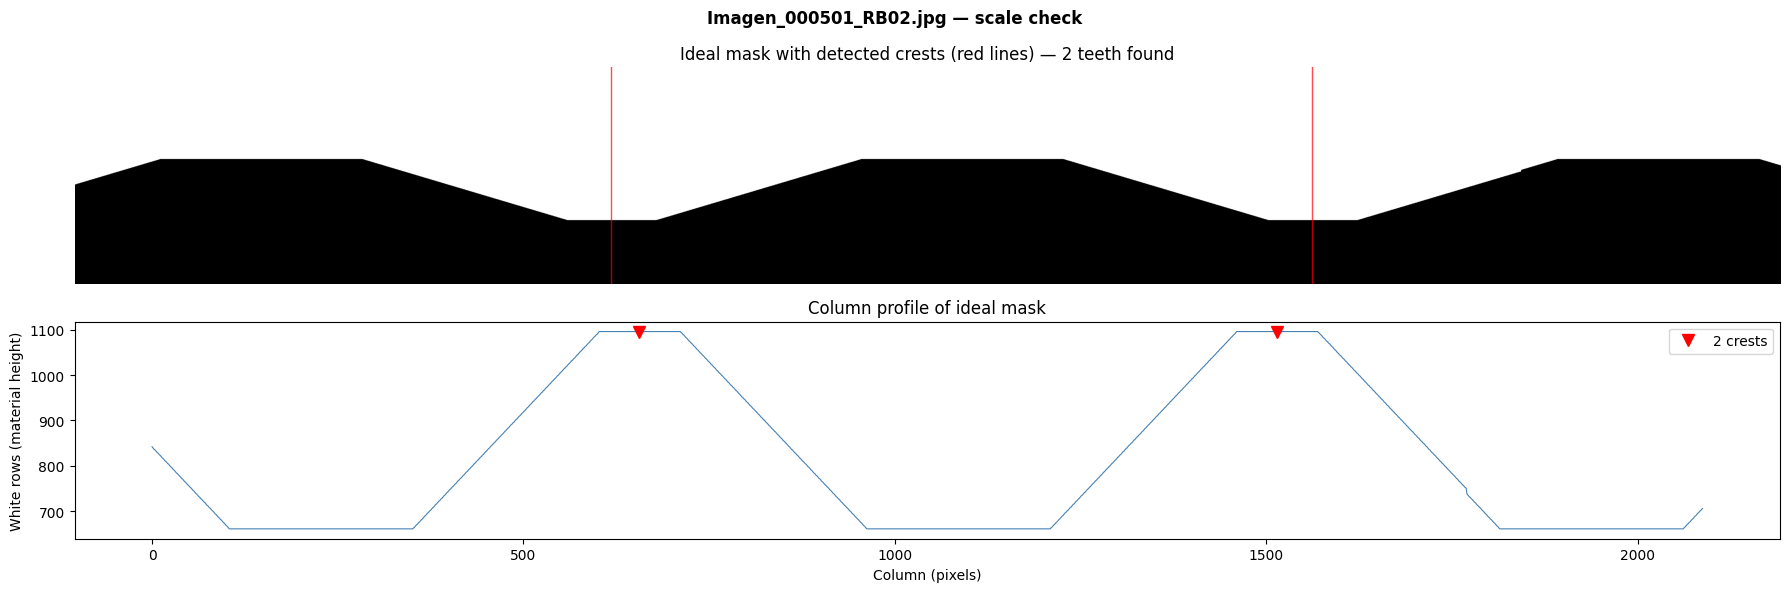

Detected 2 teeth
Mean tooth spacing: 858 px
Implied px/mm from mask: 572.0  (configured: 572.0)


In [9]:
from scipy.signal import find_peaks

# RB01 has tap head on right (atypical) — use RB02 as reference
img_path = SAMPLE_IMAGES[1]
roi_mask, tool_roi = load_roi(img_path)
ideal, _, boundary = build_ideal(roi_mask, tool_roi, flip=True)

H, W = ideal.shape

# Horizontal profile: for each column, how many rows are white (material)?
# A tooth crest = local maximum of this profile
col_profile = ideal.sum(axis=0) / 255  # count of white rows per column

# Find peaks (tooth crests) — min distance = half a pitch
min_dist = int(PITCH_MM * PX_PER_MM * 0.5)
peaks, _ = find_peaks(col_profile, distance=min_dist, prominence=5)

fig, axes = plt.subplots(2, 1, figsize=(18, 6))
fig.suptitle(f"{img_path.name} — scale check", fontsize=12, fontweight="bold")

axes[0].imshow(ideal, cmap="gray", aspect="auto")
for p in peaks:
    axes[0].axvline(p, color="red", linewidth=1, alpha=0.7)
axes[0].set_title(f"Ideal mask with detected crests (red lines) — {len(peaks)} teeth found")
axes[0].axis("off")

axes[1].plot(col_profile, linewidth=0.8, color="steelblue")
axes[1].plot(peaks, col_profile[peaks], "rv", markersize=8, label=f"{len(peaks)} crests")
axes[1].set_xlabel("Column (pixels)")
axes[1].set_ylabel("White rows (material height)")
axes[1].set_title("Column profile of ideal mask")
axes[1].legend()

plt.tight_layout()
plt.show()

if len(peaks) > 1:
    spacings = np.diff(peaks)
    mean_spacing_px = spacings.mean()
    measured_px_per_mm = mean_spacing_px / PITCH_MM
    print(f"Detected {len(peaks)} teeth")
    print(f"Mean tooth spacing: {mean_spacing_px:.0f} px")
    print(f"Implied px/mm from mask: {measured_px_per_mm:.1f}  (configured: {PX_PER_MM})")
else:
    print("WARNING: fewer than 2 teeth detected — check PX_PER_MM or PITCH_MM")

## 7. Full validation — all sample images

4-panel view for every sample image. Quick visual pass to confirm consistency.

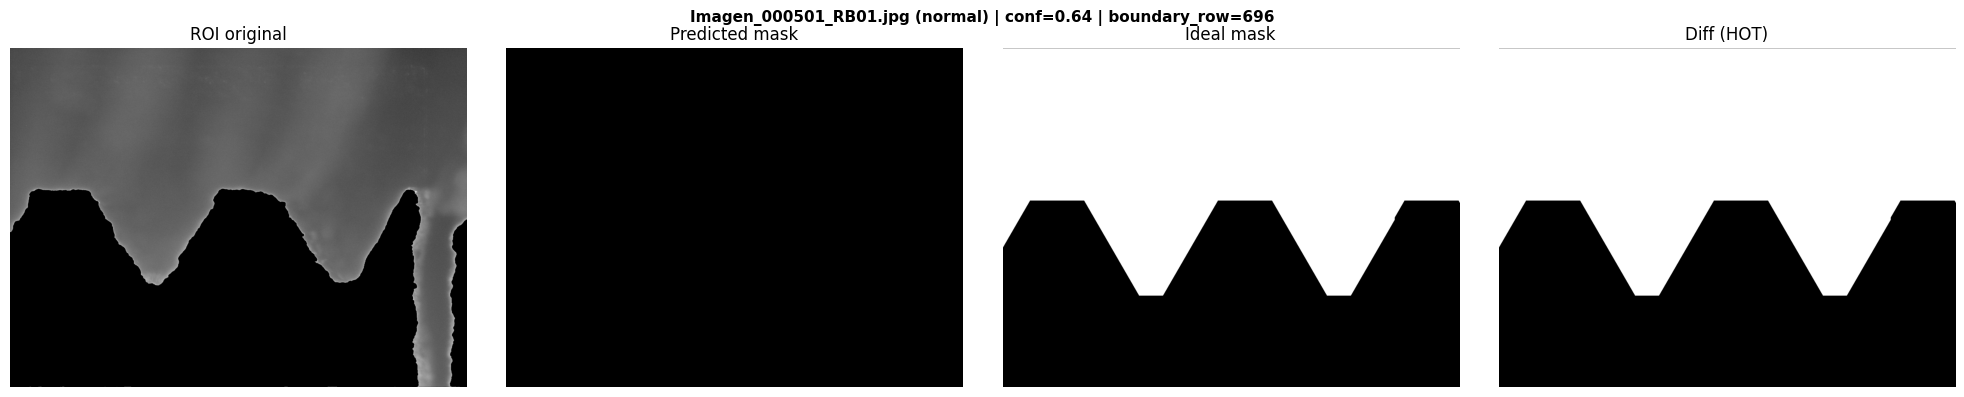

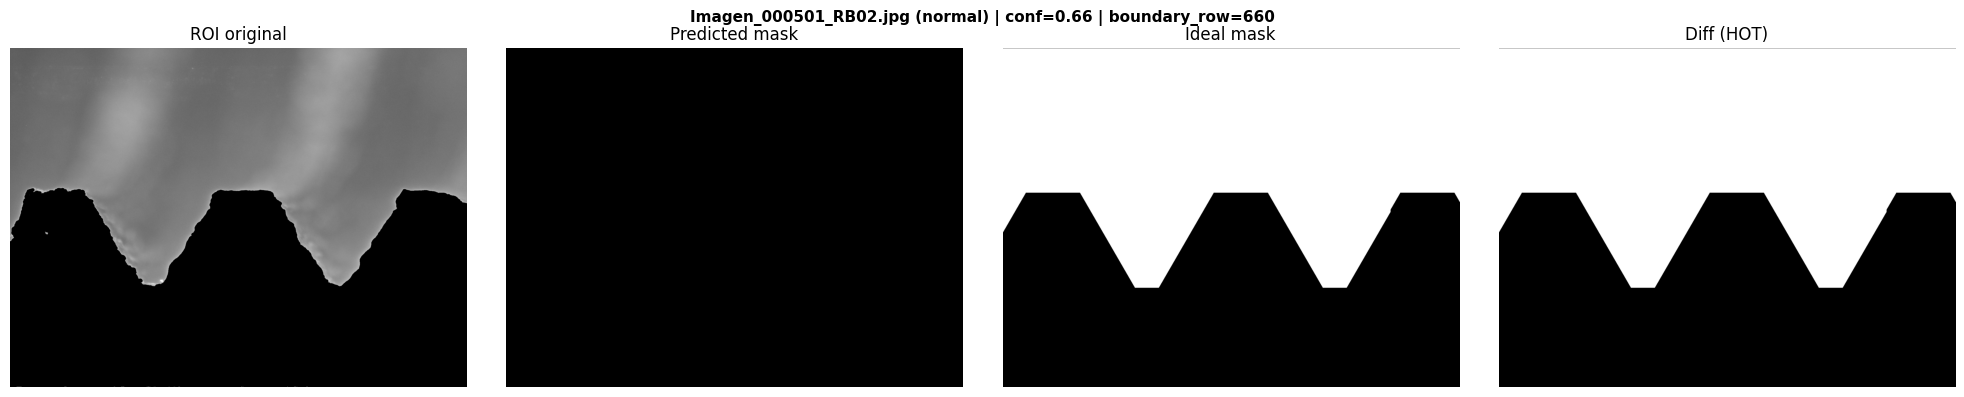

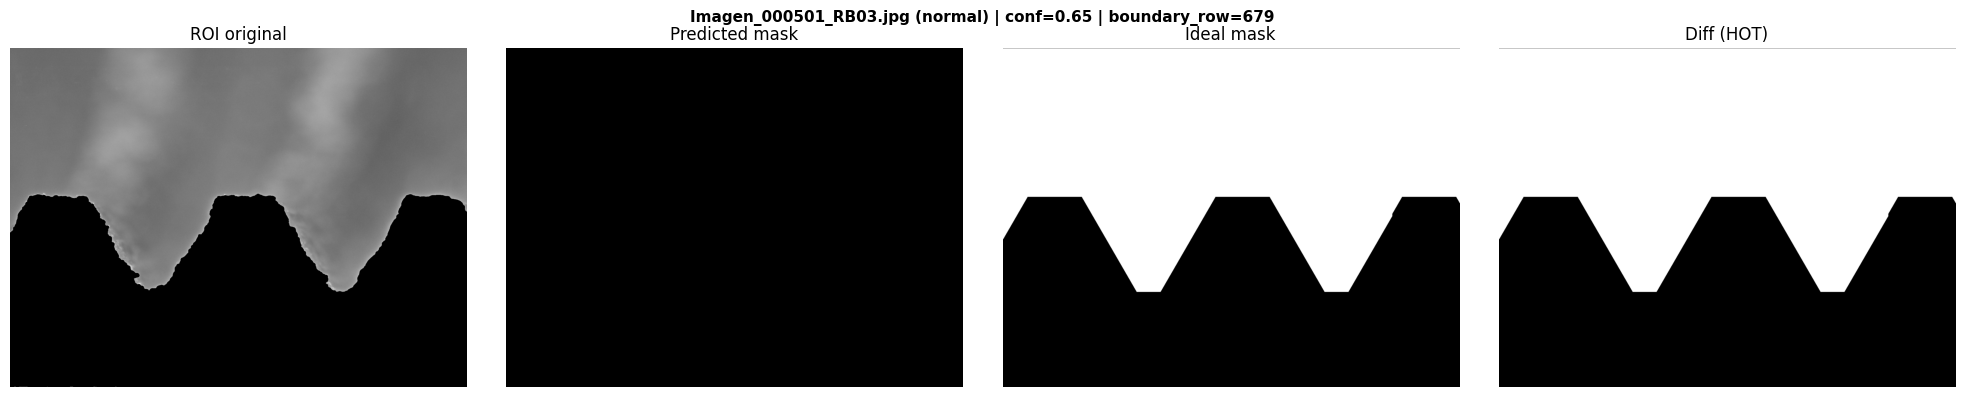

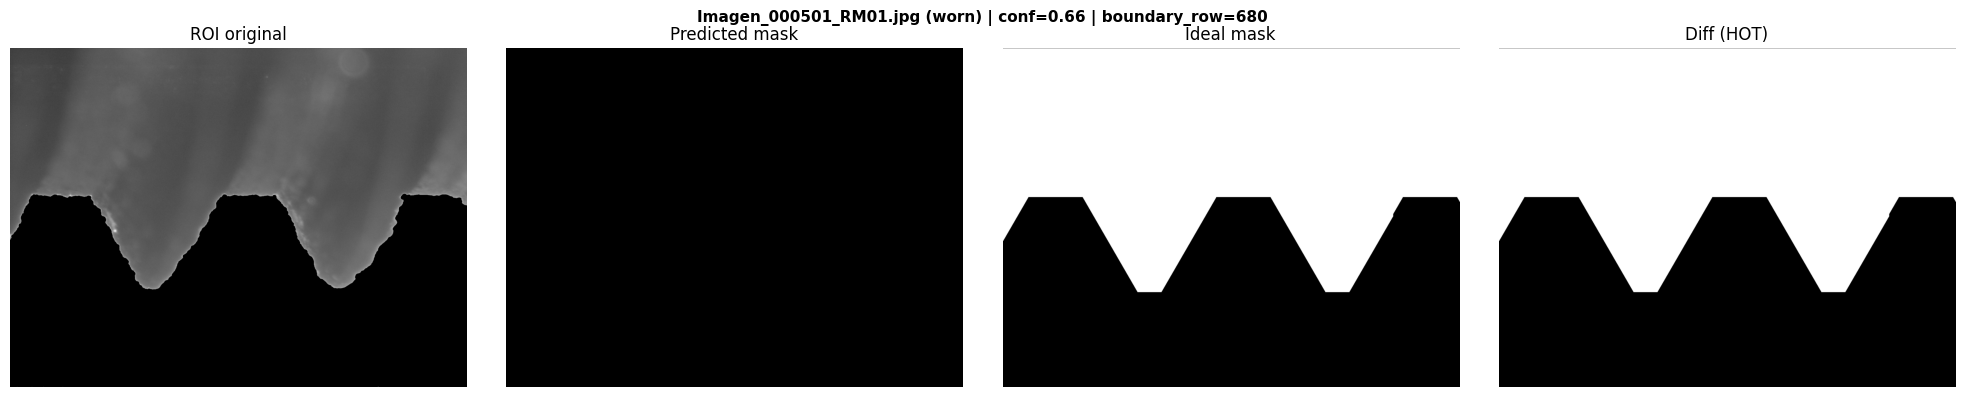

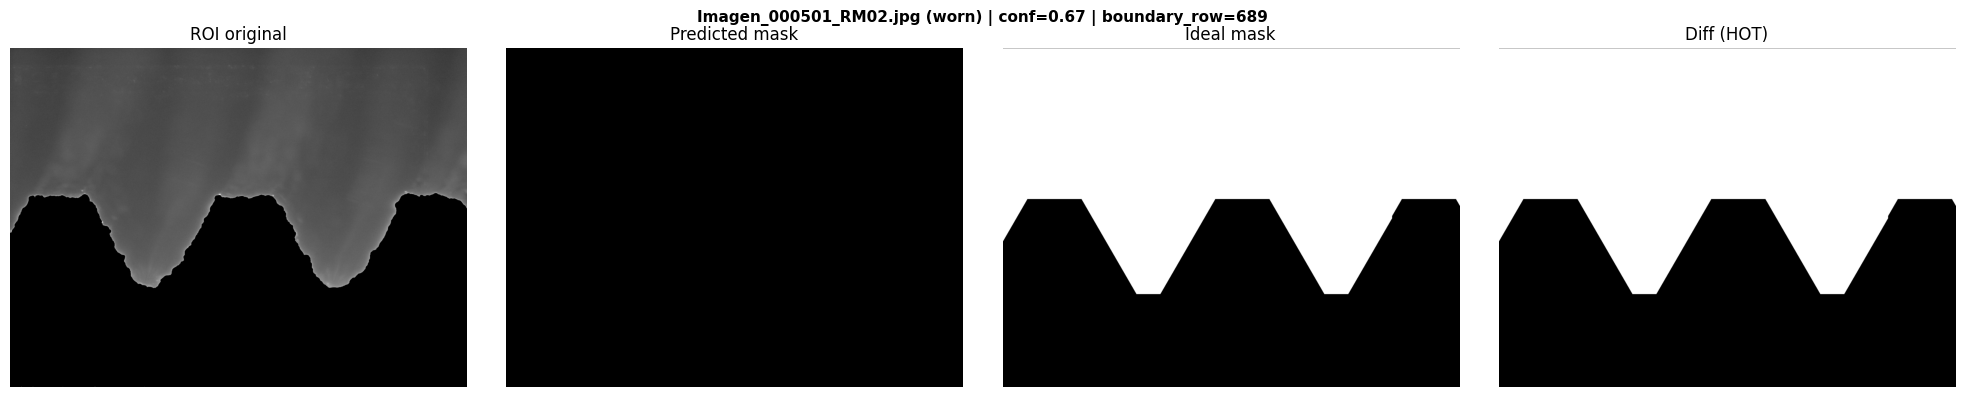

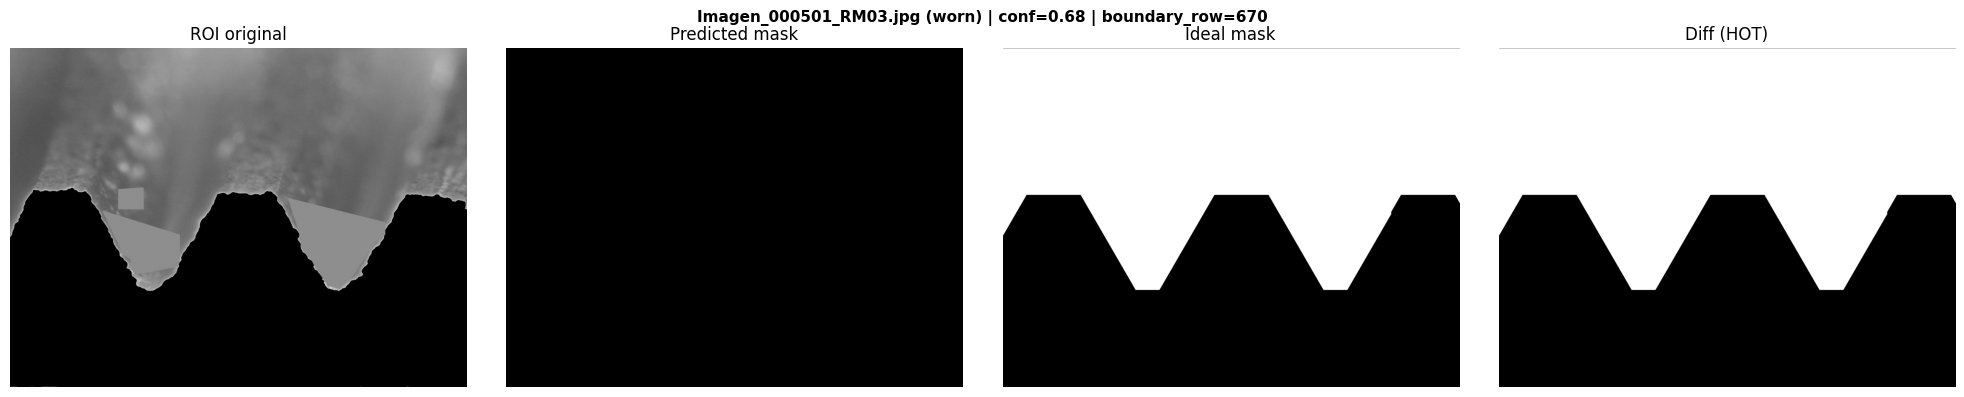

In [10]:
for img_path in SAMPLE_IMAGES:
    try:
        roi_mask, tool_roi = load_roi(img_path)
        ideal, confidence, boundary = build_ideal(roi_mask, tool_roi, flip=True)
        label = "normal" if img_path.parent.name == "normal" else "worn"
        show_4panel(
            tool_roi, ideal,
            title=f"{img_path.name} ({label}) | conf={confidence:.2f} | boundary_row={boundary}",
            roi_mask=roi_mask,
        )
    except Exception as e:
        print(f"ERROR processing {img_path.name}: {e}")

## ✓ Validation checklist

Before running Kaggle, confirm all of these:

- [ ] **Orientation:** tooth valleys in panel 3 (ideal) point **downward**, matching panel 1 (ROI)
- [ ] **Scale:** roughly same number of teeth visible in panel 1 and panel 3
- [ ] **Crest shape:** teeth in panel 3 look nearly triangular (not wide flat-topped)
- [ ] **Registration:** the tooth boundary in panel 3 aligns vertically with the tooth boundary in panel 1
- [ ] **Diff panel:** diff (panel 4) shows discrepancy only at the tooth boundary, not over the entire image

If any check fails → fix the parameter in the `Configuration` cell and re-run.